# Advertising Click-Through Rate Prediction

This project predicts whether an online advertisement will be clicked using machine learning.

The workflow includes:
- Data loading and cleaning
- Exploratory data analysis
- Feature engineering and preprocessing
- Logistic Regression baseline modeling
- XGBoost modeling
- Model comparison using ROC-AUC and Log Loss
- XGBoost feature importance analysis

**Dataset size:** 404,290 advertising impressions

## 1. Setup and Data Loading

The dataset is loaded with `id` stored as a string so the identifier is not interpreted as a numeric feature.
The original index-like `Unnamed: 0` column is removed before analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

from xgboost import XGBClassifier

# Update this path if the dataset is stored elsewhere.
DATA_PATH = "/content/drive/MyDrive/train_data/filtered_train.csv"

df = pd.read_csv(DATA_PATH, dtype={"id": str})

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)
df.head()

## 2. Dataset Overview

In [ ]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Overall CTR:", df["click"].mean())
print("Unique IDs:", df["id"].nunique())
print("Duplicate IDs:", df["id"].duplicated().sum())

## 3. Exploratory Data Analysis

### CTR by Banner Position

In [ ]:
banner_summary = df.groupby("banner_pos")["click"].agg(["count", "mean"])
banner_summary

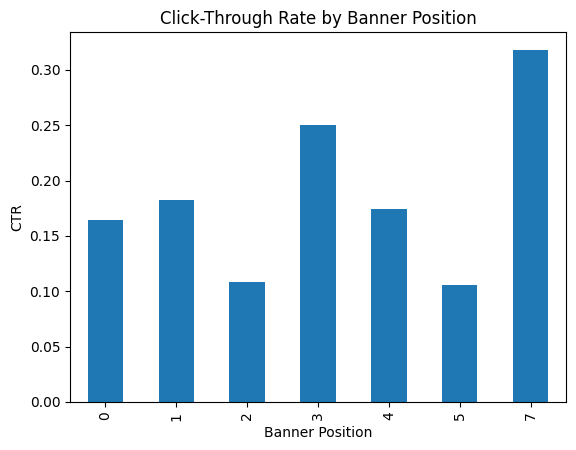

In [ ]:
banner_summary["mean"].plot(kind="bar")

plt.title("Click-Through Rate by Banner Position")
plt.xlabel("Banner Position")
plt.ylabel("CTR")
plt.show()

### CTR by Hour of Day

The hour-of-day feature is extracted from the original `hour` field.

In [ ]:
df["hour_of_day"] = df["hour"].astype(str).str[-2:].astype(int)

hour_summary = df.groupby("hour_of_day")["click"].agg(["count", "mean"])
hour_summary

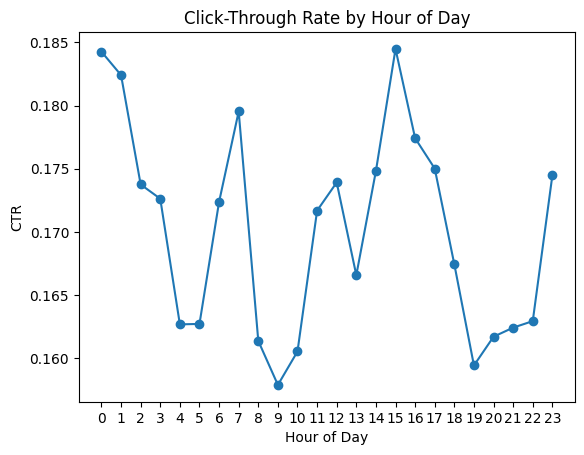

In [ ]:
hour_summary["mean"].plot(kind="line", marker="o")

plt.title("Click-Through Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("CTR")
plt.xticks(range(24))
plt.show()

## 4. Feature Preparation

The identifier column and original `hour` field are excluded from modeling.
The selected variables are treated as categorical features and one-hot encoded.

In [ ]:
df = df.drop(columns=["id", "hour"])

model_categorical_cols = [
    "site_category",
    "app_domain",
    "app_category",
    "device_type",
    "device_conn_type",
    "banner_pos",
    "hour_of_day",
    "C1",
    "C14",
    "C15",
    "C16",
    "C17",
    "C18",
    "C19",
    "C20",
    "C21"
]

X = df[model_categorical_cols]
y = df["click"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train CTR:", y_train.mean())
print("Test CTR:", y_test.mean())

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            model_categorical_cols
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

(323432, 2969)
(80858, 2969)


## 5. Logistic Regression Baseline

In [ ]:
log_model = LogisticRegression(
    solver="saga",
    max_iter=500,
    random_state=42
)

log_model.fit(X_train_processed, y_train)

log_pred_prob = log_model.predict_proba(X_test_processed)[:, 1]

log_auc = roc_auc_score(y_test, log_pred_prob)
log_loss_value = log_loss(y_test, log_pred_prob)

print("Logistic Regression ROC-AUC:", log_auc)
print("Logistic Regression Log Loss:", log_loss_value)

Logistic Regression ROC-AUC: 0.7058612910581299
Logistic Regression Log Loss: 0.41551184582794104


## 6. XGBoost Model

XGBoost is used as a nonlinear model to capture relationships and interactions that Logistic Regression may not represent.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_processed, y_train)

xgb_pred_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_pred_prob)
xgb_loss_value = log_loss(y_test, xgb_pred_prob)

print("XGBoost ROC-AUC:", xgb_auc)
print("XGBoost Log Loss:", xgb_loss_value)

XGBoost ROC-AUC: 0.7192887948132609
XGBoost Log Loss: 0.410183288855589


## 7. Model Comparison

In [ ]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "ROC-AUC": [log_auc, xgb_auc],
    "Log Loss": [log_loss_value, xgb_loss_value]
})

model_results

,Model,ROC-AUC,Log Loss
0,Logistic Regression,0.705861,0.415512
1,XGBoost,0.719289,0.410183


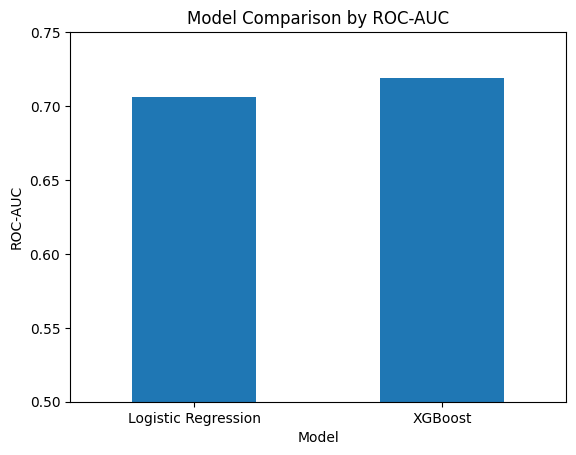

In [ ]:
model_results.plot(
    x="Model",
    y="ROC-AUC",
    kind="bar",
    legend=False
)

plt.title("Model Comparison by ROC-AUC")
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 0.75)
plt.xticks(rotation=0)
plt.show()

XGBoost achieved the stronger result, improving ROC-AUC from **0.7059** to **0.7193** and reducing Log Loss from **0.4155** to **0.4102**.

## 8. XGBoost Feature Importance

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
2681,cat__C18_2,0.051408
2680,cat__C18_1,0.049260
2263,cat__C16_250,0.032739
2261,cat__C16_50,0.024531
2925,cat__C21_61,0.023495
2917,cat__C21_33,0.019548
2924,cat__C21_52,0.015621
2334,cat__C17_1872,0.015107
2929,cat__C21_71,0.013674
2710,cat__C19_431,0.008804


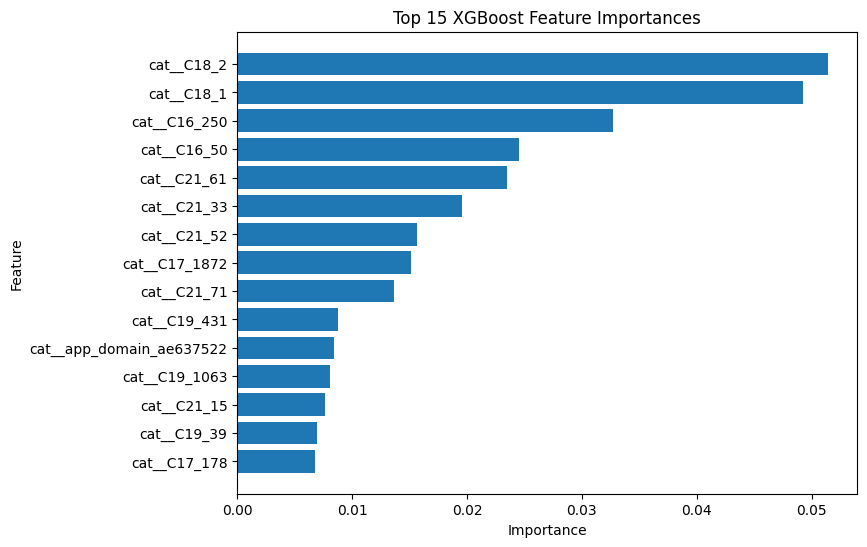

In [ ]:
top_features = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 9. Conclusion

Two machine learning approaches were evaluated for click-through rate prediction:

| Model | ROC-AUC | Log Loss |
|---|---:|---:|
| Logistic Regression | 0.7059 | 0.4155 |
| XGBoost | **0.7193** | **0.4102** |

XGBoost produced the best performance on both evaluation metrics in this experiment.
The project demonstrates an end-to-end workflow from exploratory analysis and feature preprocessing through model evaluation and interpretation.